# PBV v4 — Logistic Regression with **Deep** Order Book Imbalance (levels 2–5)

## Motivation — why drop level 1?

The first OBI attempt (`pbv_v4_logistic_imbalance.ipynb`) used inverse-distance weighting across **all 5 levels**. Diagnostics showed this failed for INTC/MSFT:
- `corr(v_obi, v_mid)` = **0.86 / 0.87** — OBI collapsed to a proxy of Level-1 imbalance.
- Univariate AUC of `v_obi` on INTC/MSFT ≈ **0.32** (inverse predictor — bid pressure at L1 preceded ask-price *rises*, classic adverse selection in tight-spread names).
- Full model **hurt** GOOG/INTC, made MSFT mean P&L negative.

Root cause: `1/distance` weighting exploded at L1 and drowned out deeper levels — exactly where Lecture 8's hidden liquidity actually sits.

## Fix implemented here

`v_obi` is now computed over levels **2–5 only** (L1 excluded). `v_mid` already captures the Level-1 picture; `v_obi` now carries **complementary** information from the deep book. Everything else (feature sets, ablation, fallback, evaluation) is identical to the previous notebook so any difference is attributable to the OBI formulation alone.

Expect:
1. `corr(v_obi, v_mid)` to drop materially (target < 0.4 for INTC/MSFT).
2. `v_obi` univariate AUC to move above 0.5 for low-H stocks (if the hidden-liquidity hypothesis holds).
3. Full-model ablation gain > 0 for INTC/MSFT without regressing GOOG/AMZN.

In [1]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

STOCK            = "INTC"
SIDE             = "BUY"
WARMUP_TICKS     = 30
THRESHOLD        = 0.5
TRAIN_FRAC       = 0.70
FALLBACK_ELAPSED = 45.0   # fixed-time fallback — execute here if model never fires
EPS              = 1e-6

EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"

# Three feature sets for ablation
FEAT_BASE = [
    "v_ask_near_d2", "v_ask_far_d2", "v_bid_near_d2", "v_bid_far_d2", "v_mid_d2",
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
]
FEAT_OBI_ONLY = ["v_obi", "v_obi_cum", "v_obi_d1"]
FEAT_FULL = FEAT_BASE + FEAT_OBI_ONLY          # base + OBI
FEAT_LEAN = [                                   # drop d2, keep OBI
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
] + FEAT_OBI_ONLY

print(f"Side: {SIDE} | Exec col: {EXEC_PRICE_COL}")
print(f"Warmup: {WARMUP_TICKS} ticks | Threshold: {THRESHOLD} | Fallback: {FALLBACK_ELAPSED}s")
print(f"FEAT_BASE ({len(FEAT_BASE)}): {FEAT_BASE}")
print(f"FEAT_FULL ({len(FEAT_FULL)}): {FEAT_FULL}")
print(f"FEAT_LEAN ({len(FEAT_LEAN)}): {FEAT_LEAN}")

Side: BUY | Exec col: AskPrice_1
Warmup: 30 ticks | Threshold: 0.5 | Fallback: 45.0s
FEAT_BASE (12): ['v_ask_near_d2', 'v_ask_far_d2', 'v_bid_near_d2', 'v_bid_far_d2', 'v_mid_d2', 'v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed']
FEAT_FULL (15): ['v_ask_near_d2', 'v_ask_far_d2', 'v_bid_near_d2', 'v_bid_far_d2', 'v_mid_d2', 'v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum', 'v_obi_d1']
FEAT_LEAN (10): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum', 'v_obi_d1']


In [2]:
# ============================================================
# CELL 2: Data Load + Bucket + OBI Computation (DEEP — levels 2-5)
# ============================================================
# v_obi: depth-weighted order book imbalance across levels 2-5 ONLY.
# Level 1 is deliberately excluded — it is already captured by v_mid
# and, under inverse-distance weighting, dominates the sum and makes
# v_obi collinear with v_mid (previous notebook: corr ≈ 0.86-0.87 for
# INTC/MSFT, with negative univariate AUC).
#
# By restricting to L2-L5, v_obi now carries the "hidden liquidity"
# signal from the deep book — precisely the regime Lecture 8 flagged
# for low-H stocks (INTC H=0.12, MSFT H=0.11).

OBI_LEVELS = range(2, 6)   # <<< key change: was range(1, 6)

def load_and_compute(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()
    d["tick_in_minute"] = d.groupby("Minute").cumcount()

    mid = d["MidPrice"]

    # --- pressure buckets (same as v3) ---
    b1, a1 = d["BidSize_1"], d["AskSize_1"]
    d["v_mid"]      = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"]  = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"]  = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    # --- DEEP depth-weighted OBI (levels 2-5 only) ---
    bid_pressure = sum(
        d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in OBI_LEVELS
    )
    ask_pressure = sum(
        d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in OBI_LEVELS
    )
    d["v_obi"] = (bid_pressure - ask_pressure) / (bid_pressure + ask_pressure + EPS)

    BUCKET_COLS = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far", "v_obi"]
    grp = d.groupby("Minute")
    for col in BUCKET_COLS:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"]  = grp[f"{col}_cum"].diff()
        d[f"{col}_d2"]  = grp[f"{col}_d1"].diff()

    # label: 1 if this tick beats TWAP (minute-open price)
    twap_ref = grp[EXEC_PRICE_COL].transform("first")
    d["label"] = (d[EXEC_PRICE_COL] < twap_ref).astype(int) if SIDE == "BUY" \
                 else (d[EXEC_PRICE_COL] > twap_ref).astype(int)
    d["stock"] = stock
    return d


train_raw = load_and_compute(STOCK)

# Sanity check: does the deep OBI actually decorrelate from v_mid?
corr_check = train_raw[["v_obi", "v_mid"]].corr().iloc[0, 1]
print(f"Shape: {train_raw.shape} | Minutes: {train_raw['Minute'].nunique()}")
print(f"Label rate: {100*train_raw['label'].mean():.1f}%")
print(f"corr(v_obi, v_mid) = {corr_check:.3f}   (old all-levels version: ~0.86 for {STOCK})")
print(f"v_obi stats:")
print(train_raw[["v_obi", "v_obi_cum", "v_obi_d1"]].describe().round(4))

Shape: (430718, 63) | Minutes: 270
Label rate: 39.1%
corr(v_obi, v_mid) = 0.153   (old all-levels version: ~0.86 for INTC)
v_obi stats:
             v_obi    v_obi_cum     v_obi_d1
count  430718.0000  430718.0000  430448.0000
mean        0.0527      28.7770       0.0527
std         0.1585     371.9432       0.1585
min        -0.8194   -2377.0499      -0.8194
25%        -0.0288      -8.5841      -0.0288
50%         0.0441      20.9236       0.0441
75%         0.1246      86.4725       0.1246
max         0.9826    2572.6073       0.9826


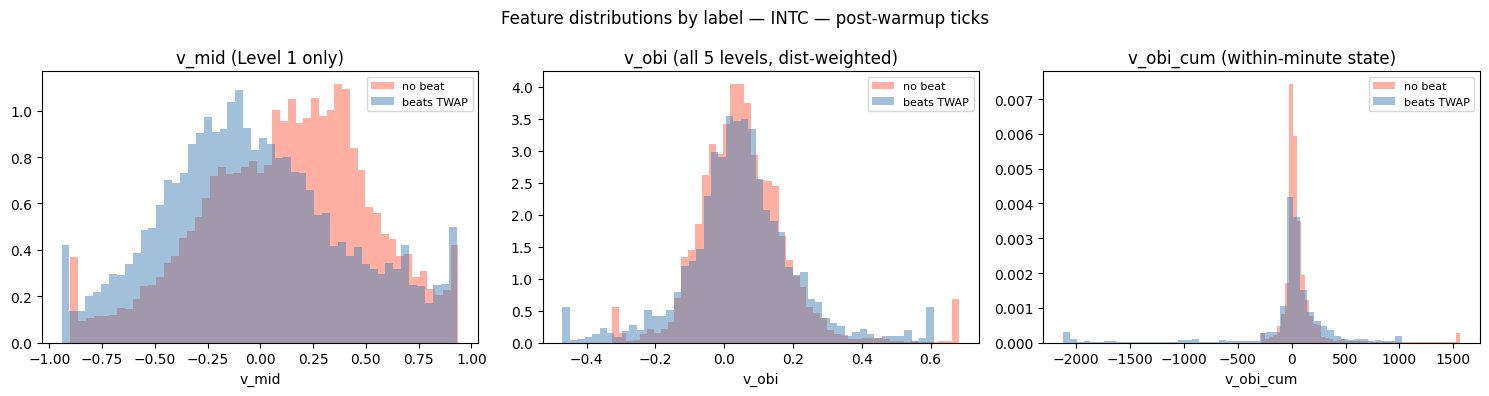

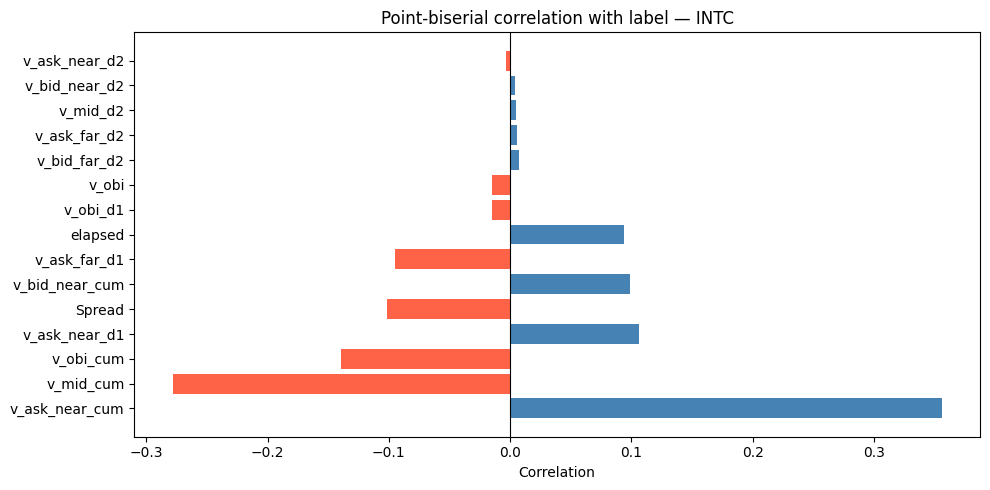

v_ask_near_cum    0.3559
v_mid_cum        -0.2782
v_obi_cum        -0.1397
v_ask_near_d1     0.1067
Spread           -0.1013
v_bid_near_cum    0.0990
v_ask_far_d1     -0.0952
elapsed           0.0937
v_obi_d1         -0.0148
v_obi            -0.0148
v_bid_far_d2      0.0077
v_ask_far_d2      0.0056
v_mid_d2          0.0049
v_bid_near_d2     0.0040
v_ask_near_d2    -0.0031

Univariate AUC — INTC:


  v_ask_near_cum             AUC=0.7223
  v_bid_near_cum             AUC=0.5704
  v_ask_near_d1              AUC=0.5600
  elapsed                    AUC=0.5548
  v_ask_near_d2              AUC=0.5179
  v_bid_far_d2               AUC=0.5086
  v_obi_d1                   AUC=0.4958 <<<
  v_obi                      AUC=0.4958 <<<
  v_ask_far_d2               AUC=0.4928
  v_bid_near_d2              AUC=0.4842
  v_obi_cum                  AUC=0.4810 <<<
  v_mid_d2                   AUC=0.4729
  v_ask_far_d1               AUC=0.4711
  Spread                     AUC=0.4610
  v_mid_cum                  AUC=0.2435


In [3]:
# ============================================================
# CELL 3: OBI Feature Analysis — Is It Actually Useful?
# ============================================================
# 1. Distribution of v_obi / v_mid split by label
# 2. Point-biserial correlation of each feature with label
# 3. Univariate AUC for key features

ALL_FEAT = FEAT_FULL
df_all = train_raw[train_raw["tick_in_minute"] >= WARMUP_TICKS].dropna(subset=ALL_FEAT).copy()

# --- 1. v_obi vs v_mid distributions by label ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, title in [
    (axes[0], "v_mid",    "v_mid (Level 1 only)"),
    (axes[1], "v_obi",    "v_obi (all 5 levels, dist-weighted)"),
    (axes[2], "v_obi_cum", "v_obi_cum (within-minute state)"),
]:
    for label, color, name in [(0, "tomato", "no beat"), (1, "steelblue", "beats TWAP")]:
        vals = df_all.loc[df_all["label"] == label, feat]
        vals_clipped = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals_clipped, bins=50, alpha=0.5, color=color, label=name, density=True, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.suptitle(f"Feature distributions by label — {STOCK} — post-warmup ticks", fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Correlations with label ---
corr = df_all[ALL_FEAT + ["label"]].corr()["label"].drop("label").sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if v > 0 else "tomato" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="none")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Point-biserial correlation with label — {STOCK}")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()
print(corr.round(4).to_string())

# --- 3. Univariate AUC ---
print(f"\nUnivariate AUC — {STOCK}:")
aucs = {}
for feat in ALL_FEAT:
    vals = df_all[feat].fillna(df_all[feat].median())
    aucs[feat] = roc_auc_score(df_all["label"], vals)
aucs_s = pd.Series(aucs).sort_values(ascending=False)
for feat, auc in aucs_s.items():
    marker = " <<<" if feat in FEAT_OBI_ONLY else ""
    print(f"  {feat:25s}  AUC={auc:.4f}{marker}")

In [4]:
# ============================================================
# CELL 4: Train/Test Split + Build Feature Matrices
# ============================================================

df = train_raw[train_raw["tick_in_minute"] >= WARMUP_TICKS].dropna(subset=FEAT_FULL).copy()

minutes_sorted = sorted(df["Minute"].unique())
n_train = int(len(minutes_sorted) * TRAIN_FRAC)
train_mins = set(minutes_sorted[:n_train])
test_mins  = set(minutes_sorted[n_train:])

df_train = df[df["Minute"].isin(train_mins)]
df_test  = df[df["Minute"].isin(test_mins)]

print(f"Post-warmup rows: {len(df)}")
print(f"Train: {len(train_mins)} minutes, {len(df_train)} rows, label={100*df_train['label'].mean():.1f}%")
print(f"Test : {len(test_mins)} minutes, {len(df_test)} rows, label={100*df_test['label'].mean():.1f}%")

Post-warmup rows: 422618
Train: 189 minutes, 325126 rows, label=42.0%
Test : 81 minutes, 97492 rows, label=32.4%


In [5]:
# ============================================================
# CELL 5: Ablation — Base vs Full vs Lean
# ============================================================
# Fit three models and compare train/test AUC to isolate OBI contribution.

def fit_model(feat_cols, df_tr, df_te):
    sc = StandardScaler()
    Xtr = sc.fit_transform(df_tr[feat_cols].values)
    Xte = sc.transform(df_te[feat_cols].values)
    m = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42)
    m.fit(Xtr, df_tr["label"].values)
    tr_auc = roc_auc_score(df_tr["label"].values, m.predict_proba(Xtr)[:, 1])
    te_auc = roc_auc_score(df_te["label"].values, m.predict_proba(Xte)[:, 1])
    return m, sc, tr_auc, te_auc

m_base, sc_base, tr_base, te_base = fit_model(FEAT_BASE, df_train, df_test)
m_full, sc_full, tr_full, te_full = fit_model(FEAT_FULL, df_train, df_test)
m_lean, sc_lean, tr_lean, te_lean = fit_model(FEAT_LEAN, df_train, df_test)

print(f"{'Model':<12} {'Features':>8}  {'Train AUC':>10}  {'Test AUC':>9}  {'AUC gain vs base':>17}")
print("-" * 62)
for name, tr, te, nf in [
    ("Base",  tr_base, te_base, len(FEAT_BASE)),
    ("Full",  tr_full, te_full, len(FEAT_FULL)),
    ("Lean",  tr_lean, te_lean, len(FEAT_LEAN)),
]:
    gain = te - te_base
    print(f"{name:<12} {nf:>8}  {tr:>10.4f}  {te:>9.4f}  {gain:>+17.4f}")

print(f"\nFull model coefficients — {STOCK}:")
coef_df = pd.DataFrame({
    "feature": FEAT_FULL,
    "coef":    m_full.coef_[0],
}).sort_values("coef")
for _, row in coef_df.iterrows():
    marker = " <<<" if row["feature"] in FEAT_OBI_ONLY else ""
    print(f"  {row['feature']:25s}  {row['coef']:+.4f}{marker}")

Model        Features   Train AUC   Test AUC   AUC gain vs base
--------------------------------------------------------------
Base               12      0.8261     0.7956            +0.0000
Full               15      0.8338     0.7964            +0.0008
Lean               10      0.8337     0.7964            +0.0008

Full model coefficients — INTC:
  v_ask_far_d1               -1.1870
  v_mid_cum                  -0.5043
  Spread                     -0.4482
  v_obi_cum                  -0.4370 <<<
  v_bid_near_cum             -0.3738
  elapsed                    -0.1555
  v_ask_near_d2              -0.0004
  v_bid_far_d2               +0.0093
  v_obi                      +0.0153 <<<
  v_obi_d1                   +0.0153 <<<
  v_bid_near_d2              +0.0181
  v_mid_d2                   +0.0190
  v_ask_far_d2               +0.0292
  v_ask_near_d1              +0.4429
  v_ask_near_cum             +1.6209


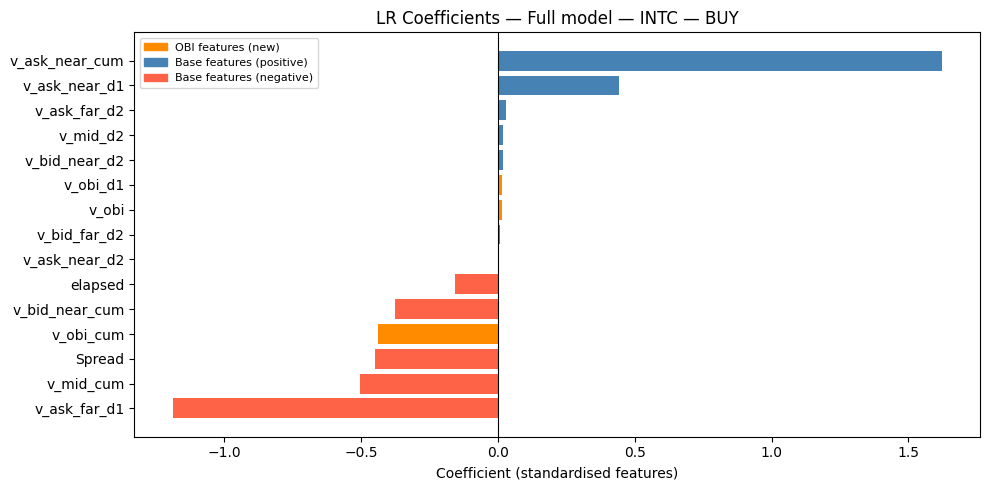

In [6]:
# ============================================================
# CELL 6: Coefficient Chart — Full Model
# ============================================================

coef_df_sorted = coef_df.sort_values("coef")
colors = ["darkorange" if f in FEAT_OBI_ONLY else
          ("steelblue" if c > 0 else "tomato")
          for f, c in zip(coef_df_sorted["feature"], coef_df_sorted["coef"])]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef_df_sorted["feature"], coef_df_sorted["coef"], color=colors, edgecolor="none")
ax.axvline(0, color="black", lw=0.8)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="darkorange", label="OBI features (new)"),
    Patch(color="steelblue",  label="Base features (positive)"),
    Patch(color="tomato",     label="Base features (negative)"),
], fontsize=8)
ax.set_title(f"LR Coefficients — Full model — {STOCK} — {SIDE}")
ax.set_xlabel("Coefficient (standardised features)")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: Simulate Execution — Full Model vs Base Model vs v3
# ============================================================
# Fallback: instead of last tick, execute at the tick closest to
# FALLBACK_ELAPSED seconds (fixed-time fallback, more predictable).

def simulate(model, scaler, feat_cols, df_te_scored_arg, df_raw, label):
    df_s = df_te_scored_arg.copy()
    df_s["prob"] = model.predict_proba(
        scaler.transform(df_s[feat_cols].values)
    )[:, 1]

    rows = []
    for minute, grp in df_s.groupby("Minute"):
        grp = grp.sort_values("elapsed")
        twap_price = df_raw.loc[df_raw["Minute"] == minute, EXEC_PRICE_COL].iloc[0]

        fired = grp[grp["prob"] >= THRESHOLD]
        if not fired.empty:
            exec_row   = fired.iloc[0]
            model_fire = True
        else:
            # fixed-time fallback: tick closest to FALLBACK_ELAPSED
            all_minute = df_raw[df_raw["Minute"] == minute].sort_values("elapsed")
            idx = (all_minute["elapsed"] - FALLBACK_ELAPSED).abs().idxmin()
            exec_row   = all_minute.loc[idx]
            model_fire = False

        pbv_price   = exec_row[EXEC_PRICE_COL]
        improvement = (twap_price - pbv_price) if SIDE == "BUY" else (pbv_price - twap_price)
        rows.append({
            "improvement": improvement,
            "exec_s":      exec_row["elapsed"],
            "model_fire":  model_fire,
        })

    r = pd.DataFrame(rows)
    mf = r[r["model_fire"]]
    print(f"\n{'='*55}\n  {label} — {STOCK}")
    print(f"  Minutes        : {len(r)}")
    print(f"  Model fired    : {r['model_fire'].sum()} ({100*r['model_fire'].mean():.1f}%)")
    print(f"  Mean improv.   : ${r['improvement'].mean():.5f}")
    print(f"  % beat TWAP    : {100*(r['improvement'] > 0).mean():.1f}%")
    print(f"  Fire beat TWAP : {100*(mf['improvement'] > 0).mean():.1f}%  (n={len(mf)})")
    print(f"  Mean exec s    : {r['exec_s'].mean():.1f}")
    return r

res_full = simulate(m_full, sc_full, FEAT_FULL, df_test, train_raw, "Full LR (base + OBI)")
res_base = simulate(m_base, sc_base, FEAT_BASE, df_test, train_raw, "Base LR (no OBI)")

# v3 base signal on test minutes
v3_rows = []
for minute, grp in df_test.groupby("Minute"):
    grp = grp.sort_values("elapsed")
    twap_price = train_raw.loc[train_raw["Minute"] == minute, EXEC_PRICE_COL].iloc[0]
    v3_sig = (grp["tick_in_minute"] >= WARMUP_TICKS) & (grp["v_ask_near_d2"] < 0) & (grp["v_mid_cum"] > 0)
    fired  = grp[v3_sig.fillna(False)]
    exec_row = fired.iloc[0] if not fired.empty else \
               train_raw[train_raw["Minute"] == minute].sort_values("elapsed").iloc[
                   (train_raw[train_raw["Minute"] == minute]["elapsed"] - FALLBACK_ELAPSED).abs().values.argmin()]
    v3_rows.append({"improvement": (twap_price - exec_row[EXEC_PRICE_COL]) if SIDE == "BUY" else (exec_row[EXEC_PRICE_COL] - twap_price)})
res_v3 = pd.DataFrame(v3_rows)
print(f"\n{'='*55}\n  v3 base signal — {STOCK}")
print(f"  Mean improv.   : ${res_v3['improvement'].mean():.5f}")
print(f"  % beat TWAP    : {100*(res_v3['improvement'] > 0).mean():.1f}%")


  Full LR (base + OBI) — INTC
  Minutes        : 81
  Model fired    : 52 (64.2%)
  Mean improv.   : $0.00025
  % beat TWAP    : 27.2%
  Fire beat TWAP : 42.3%  (n=52)
  Mean exec s    : 31.0



  Base LR (no OBI) — INTC
  Minutes        : 81
  Model fired    : 50 (61.7%)
  Mean improv.   : $0.00012
  % beat TWAP    : 27.2%
  Fire beat TWAP : 44.0%  (n=50)
  Mean exec s    : 33.0



  v3 base signal — INTC
  Mean improv.   : $0.00173
  % beat TWAP    : 17.3%


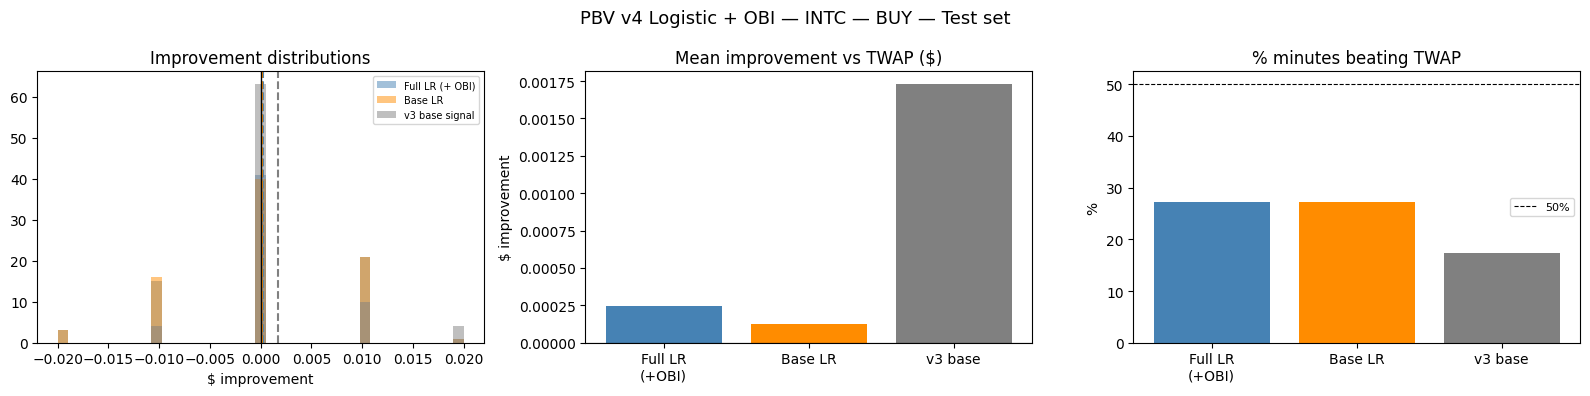

In [8]:
# ============================================================
# CELL 8: Results Visualisation — Full vs Base vs v3
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

bins = np.linspace(
    min(res_full["improvement"].min(), res_base["improvement"].min()),
    max(res_full["improvement"].max(), res_base["improvement"].max()), 40
)

for res, label, color in [
    (res_full, "Full LR (+ OBI)", "steelblue"),
    (res_base, "Base LR",         "darkorange"),
    (res_v3,   "v3 base signal",  "gray"),
]:
    axes[0].hist(res["improvement"], bins=bins, alpha=0.5, color=color, label=label, edgecolor="none")
    axes[0].axvline(res["improvement"].mean(), color=color, lw=1.5, ls="--")

axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Improvement distributions")
axes[0].set_xlabel("$ improvement")
axes[0].legend(fontsize=7)

cats  = ["Full LR\n(+OBI)", "Base LR", "v3 base"]
means = [res_full["improvement"].mean(), res_base["improvement"].mean(), res_v3["improvement"].mean()]
beats = [100*(res_full["improvement"]>0).mean(), 100*(res_base["improvement"]>0).mean(), 100*(res_v3["improvement"]>0).mean()]
clrs  = ["steelblue", "darkorange", "gray"]

axes[1].bar(cats, means, color=clrs, edgecolor="none")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Mean improvement vs TWAP ($)")
axes[1].set_ylabel("$ improvement")

axes[2].bar(cats, beats, color=clrs, edgecolor="none")
axes[2].axhline(50, color="black", lw=0.8, ls="--", label="50%")
axes[2].set_title("% minutes beating TWAP")
axes[2].set_ylabel("%")
axes[2].legend(fontsize=8)

plt.suptitle(f"PBV v4 Logistic + OBI — {STOCK} — {SIDE} — Test set", fontsize=13)
plt.tight_layout()
plt.show()

Running cross-stock pipeline...


Done.

Stock   Model      AUC     Mean $   Beat %   Fire %
--------------------------------------------------
AMZN    base     0.597    0.01444     49.4    100.0
AMZN    full     0.683    0.01185     44.4     96.3
AMZN    lean     0.683    0.00988     43.2     96.3

GOOG    base     0.601    0.03568     60.5     96.3
GOOG    full     0.605    0.02938     60.5     95.1
GOOG    lean     0.605    0.02802     59.3     95.1

INTC    base     0.796    0.00012     27.2     61.7
INTC    full     0.796    0.00025     27.2     64.2
INTC    lean     0.796    0.00000     27.2     63.0

MSFT    base     0.898    0.00025     42.0     46.9
MSFT    full     0.908    0.00025     42.0     46.9
MSFT    lean     0.908    0.00037     42.0     46.9



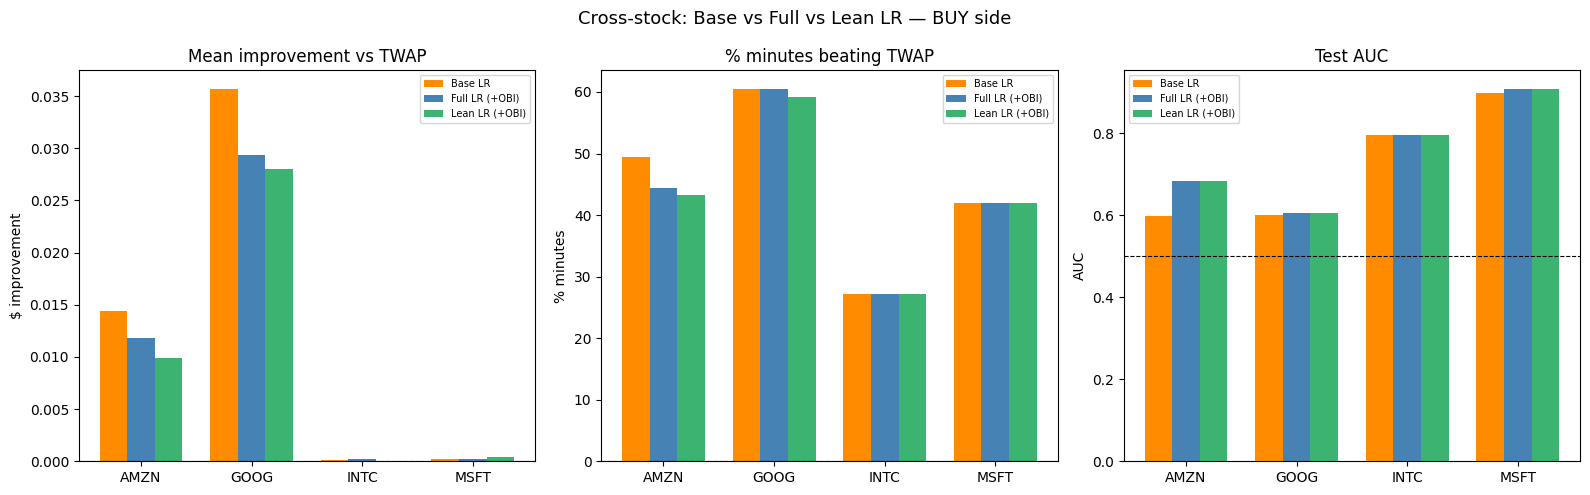

In [9]:
# ============================================================
# CELL 9: Cross-Stock Evaluation
# ============================================================

STOCKS_ALL = ["AMZN", "GOOG", "INTC", "MSFT"]

def run_stock(stock):
    d = load_and_compute(stock)
    df = d[d["tick_in_minute"] >= WARMUP_TICKS].dropna(subset=FEAT_FULL)

    mins = sorted(df["Minute"].unique())
    n_tr = int(len(mins) * TRAIN_FRAC)
    tr_m = set(mins[:n_tr])
    te_m = set(mins[n_tr:])

    df_tr = df[df["Minute"].isin(tr_m)]
    df_te = df[df["Minute"].isin(te_m)]

    results = {}
    for name, feats in [("base", FEAT_BASE), ("full", FEAT_FULL), ("lean", FEAT_LEAN)]:
        sc = StandardScaler()
        Xtr = sc.fit_transform(df_tr[feats].values)
        Xte = sc.transform(df_te[feats].values)
        m   = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42)
        m.fit(Xtr, df_tr["label"].values)

        te_auc  = roc_auc_score(df_te["label"].values, m.predict_proba(Xte)[:, 1])
        df_te_s = df_te.copy()
        df_te_s["prob"] = m.predict_proba(Xte)[:, 1]

        rows = []
        for minute, grp in df_te_s.groupby("Minute"):
            grp = grp.sort_values("elapsed")
            twap_price = d.loc[d["Minute"] == minute, EXEC_PRICE_COL].iloc[0]
            fired = grp[grp["prob"] >= THRESHOLD]
            if not fired.empty:
                exec_row = fired.iloc[0]
            else:
                all_m = d[d["Minute"] == minute].sort_values("elapsed")
                idx   = (all_m["elapsed"] - FALLBACK_ELAPSED).abs().idxmin()
                exec_row = all_m.loc[idx]
            imp = (twap_price - exec_row[EXEC_PRICE_COL]) if SIDE == "BUY" else (exec_row[EXEC_PRICE_COL] - twap_price)
            rows.append({"improvement": imp, "model_fire": not fired.empty})

        r = pd.DataFrame(rows)
        results[name] = {
            "auc":    te_auc,
            "mean":   r["improvement"].mean(),
            "beat":   (r["improvement"] > 0).mean() * 100,
            "fire":   r["model_fire"].mean() * 100,
        }
    return results

print("Running cross-stock pipeline...")
xs = {s: run_stock(s) for s in STOCKS_ALL}
print("Done.")

print(f"\n{'Stock':<6}  {'Model':<6}  {'AUC':>6}  {'Mean $':>9}  {'Beat %':>7}  {'Fire %':>7}")
print("-" * 50)
for stock in STOCKS_ALL:
    for mname in ["base", "full", "lean"]:
        r = xs[stock][mname]
        print(f"{stock:<6}  {mname:<6}  {r['auc']:>6.3f}  {r['mean']:>9.5f}  {r['beat']:>7.1f}  {r['fire']:>7.1f}")
    print()

# Summary bar chart: mean improvement, base vs full, per stock
x, width = np.arange(len(STOCKS_ALL)), 0.25
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, ylabel, title in [
    (axes[0], "mean",  "$ improvement",    "Mean improvement vs TWAP"),
    (axes[1], "beat",  "% minutes",         "% minutes beating TWAP"),
    (axes[2], "auc",   "AUC",              "Test AUC"),
]:
    ax.bar(x - width, [xs[s]["base"][metric] for s in STOCKS_ALL], width, label="Base LR",      color="darkorange")
    ax.bar(x,          [xs[s]["full"][metric] for s in STOCKS_ALL], width, label="Full LR (+OBI)", color="steelblue")
    ax.bar(x + width,  [xs[s]["lean"][metric] for s in STOCKS_ALL], width, label="Lean LR (+OBI)", color="mediumseagreen")
    ax.axhline(0 if metric != "auc" else 0.5, color="black", lw=0.8, ls="--")
    ax.set_xticks(x); ax.set_xticklabels(STOCKS_ALL)
    ax.set(title=title, ylabel=ylabel)
    ax.legend(fontsize=7)

plt.suptitle("Cross-stock: Base vs Full vs Lean LR — BUY side", fontsize=13)
plt.tight_layout()
plt.show()